In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))

import mesmer
import model
import model_analysis

import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd

import cartopy.crs as ccrs

In [2]:
max_hist = 13
is_local_data = False
Month_idx = 4
safe = True
start_wanted = None
end = None
max_depth = 3

### Load parameters of the transformations

In [3]:
parameter_sets = {}
for i in range(1,max_hist):
    key = f"hist_{i}"
    parameter_sets[key] = model.loading.load_params(var = "mrsol",scen= "historical", folder = f"MPI-ESM1-2-LR/variations/history/{key}/local{is_local_data}/month{Month_idx}", name=f"start={start_wanted},end={end}.max_depth{max_depth}")    

the mask should only change if one is based on relative data, and one is abs because the threshold has a diffrent effect

In [4]:
for para_key,para in parameter_sets.items():
    print(parameter_sets["hist_1"]["detail_mask"].equals(para["detail_mask"]))

chunk_mask = parameter_sets["hist_1"]["chunk_mask"]


True
True
True
True
True
True
True
True
True
True
True
True


In [5]:
for para_key,para in parameter_sets.items():
    print(parameter_sets["hist_1"]["chunk_mask"].equals(para["chunk_mask"]))

detal_mask = parameter_sets["hist_1"]["detail_mask"]


True
True
True
True
True
True
True
True
True
True
True
True


In [6]:
for para_key,para in parameter_sets.items():
    print(parameter_sets["hist_1"]["local_maximas"].equals(para["local_maximas"]))

max = model.mask.mask_mask(parameter_sets["hist_1"]["local_maximas"],parameter_sets["hist_1"]["chunk_mask"].mrsol).isel(depth=slice(0, max_depth))
maximas = mesmer.grid.stack_lat_lon(max).drop_vars("depth_bnds").transpose("gridcell","depth").mrsol


True
True
True
True
True
True
True
True
True
True
True
True


### Load test input and target
Here the target is already loaded, but only used for the possible start point

In [7]:
run_idx = 4

tas_ds = model.loading.load_data_set(var = "tas", local = is_local_data, run_idx=run_idx)
pr_ds = model.loading.load_data_set(var = "pr", local = is_local_data, run_idx=run_idx)

raw_input_for_test = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")


In [8]:
#min_start 
raw_mrsol_for_test = model.loading.load_data_set(var = "mrsol", local = is_local_data, run_idx=run_idx)

data_start = pd.to_datetime(raw_mrsol_for_test.time[0].item())
offset = pd.tseries.frequencies.to_offset("ME")
min_start = data_start + pd.DateOffset(months=max_hist)

if start_wanted is None:
    start = min_start
else:
    start = pd.to_datetime(start_wanted) 
    start = max(min_start,start)
start = start.strftime("%Y-%m-%d")  

### shape inputs

In [9]:
def shape_input(ds, chunk_mask, hist):
    ds = model.shape_data.add_hist_dimension(ds, hist)    
    ds = ds.sel(time=slice(start, end)).resample(time="ME").mean()
    ds = ds.sel(time= ds.time.dt.month == Month_idx)
    ds = model.mask.mask_mask(ds,chunk_mask)
    ds = mesmer.grid.stack_lat_lon(ds)
    return ds

    

In [10]:
test_predictor_sets  = {}
test_max_predictor = shape_input(raw_input_for_test,chunk_mask.mrsol,max_hist)

for hist in range(1, max_hist):
    test_predictor_sets[f"hist_{hist}"] = test_max_predictor.isel(hist=slice(0,hist))

### Emulate

In [11]:
predictions = {}

In [12]:
for key, para in parameter_sets.items():
    predictions[key] = {}

    Regr_mean = model.stats._parallel_linear_regression_stack.ParLinearRegressionStack(predictor_dims=["hist"])
    Regr_mean = Regr_mean.from_params(para["mean"])
    predictions[key]["mean"] = Regr_mean.predict(test_predictor_sets[key],location_dim="gridcell", regr_dim="time").transpose("gridcell","time", "depth")

    Regr_var = model.stats._parallel_linear_regression_stack.ParLinearRegressionStack(predictor_dims=["hist"])
    Regr_var = Regr_var.from_params(para["variance"])
    predictions[key]["variance"] = Regr_var.predict(test_predictor_sets[key],location_dim="gridcell", regr_dim="time").transpose("gridcell","time", "depth")

        

### shape targets

In [13]:
def shape_target(ds):
    #ds = ds.clip(min = 1e-32)
    ds = ds.sel(time=slice(start, end)).resample(time="ME").mean()
    ds = ds.sel(time= ds.time.dt.month == Month_idx).isel(depth=slice(0, max_depth)).drop_vars("depth_bnds")
    return ds

In [14]:
def mask_stack_target(ds):
    masked_ds, chunk_mask, detail_mask= model.mask.mask_nonpositiv_height_chunks(ds)
    ds = mesmer.grid.stack_lat_lon(masked_ds)
    ds = ds.transpose("gridcell","time", "depth")
    return ds

In [15]:
target_unstacked = shape_target(raw_mrsol_for_test)
target = mask_stack_target(target_unstacked)

#### Scores

In [16]:
score_sets = {}


In [17]:
score_keys = parameter_sets.keys()
score_keys

dict_keys(['hist_1', 'hist_2', 'hist_3', 'hist_4', 'hist_5', 'hist_6', 'hist_7', 'hist_8', 'hist_9', 'hist_10', 'hist_11', 'hist_12'])

In [18]:
for key in score_keys:
    score_sets[key] = model_analysis.crps_score.crps_norm_score(predictions[key]["mean"],predictions[key]["variance"], target, transformation = "Logit", maximas_da = maximas,ensemble_size = 15)

In [19]:
for s_keys, scores in score_sets.items():
    score_sets[s_keys] = mesmer.grid.unstack_lat_lon_and_align(scores, target_unstacked)
    
    score_sets[s_keys] = model.mask.mask_mask(score_sets[s_keys],detal_mask.mrsol,"lon", "lat", "depth")
    

In [20]:
all_scores_ds = xr.Dataset({key : score.crps_score for key, score in score_sets.items()})

In [21]:
if safe:
    model.save.save_crps_scores(all_scores_ds, var = "mrsol",scen= "historical", folder = f"MPI-ESM1-2-LR/variations/history/all_scores/local{is_local_data}/month{Month_idx}", name=f"start={start},end={end}.max_depth{max_depth}")

In [22]:
all_scores_ds.mean(dim=["lon","lat","time"])

<xarray.Dataset> Size: 312B
Dimensions:  (depth: 3)
Coordinates:
  * depth    (depth) float64 24B 0.03 0.19 0.78
Data variables:
    hist_1   (depth) float64 24B 0.4181 1.642 6.723
    hist_2   (depth) float64 24B 0.3894 1.453 6.009
    hist_3   (depth) float64 24B 0.3879 1.429 5.684
    hist_4   (depth) float64 24B 0.3891 1.418 5.48
    hist_5   (depth) float64 24B 0.3909 1.417 5.304
    hist_6   (depth) float64 24B 0.392 1.412 5.166
    hist_7   (depth) float64 24B 0.3934 1.406 5.063
    hist_8   (depth) float64 24B 0.3928 1.394 4.961
    hist_9   (depth) float64 24B 0.3916 1.375 4.8
    hist_10  (depth) float64 24B 0.3924 1.368 4.71
    hist_11  (depth) float64 24B 0.3953 1.375 4.681
    hist_12  (depth) float64 24B 0.3997 1.386 4.702

In [23]:
all_scores_ds.mean(dim=["lon","lat","time"])-all_scores_ds.mean(dim=["lon","lat","time"]).hist_4

<xarray.Dataset> Size: 312B
Dimensions:  (depth: 3)
Coordinates:
  * depth    (depth) float64 24B 0.03 0.19 0.78
Data variables:
    hist_1   (depth) float64 24B 0.02896 0.2238 1.243
    hist_2   (depth) float64 24B 0.0002685 0.03525 0.5286
    hist_3   (depth) float64 24B -0.001194 0.01166 0.2045
    hist_4   (depth) float64 24B 0.0 0.0 0.0
    hist_5   (depth) float64 24B 0.001807 -0.0002953 -0.1761
    hist_6   (depth) float64 24B 0.002818 -0.00536 -0.3139
    hist_7   (depth) float64 24B 0.004212 -0.01135 -0.4169
    hist_8   (depth) float64 24B 0.003641 -0.0238 -0.5191
    hist_9   (depth) float64 24B 0.002461 -0.04233 -0.6801
    hist_10  (depth) float64 24B 0.00321 -0.04993 -0.7696
    hist_11  (depth) float64 24B 0.006186 -0.0427 -0.7989
    hist_12  (depth) float64 24B 0.01056 -0.03169 -0.7777

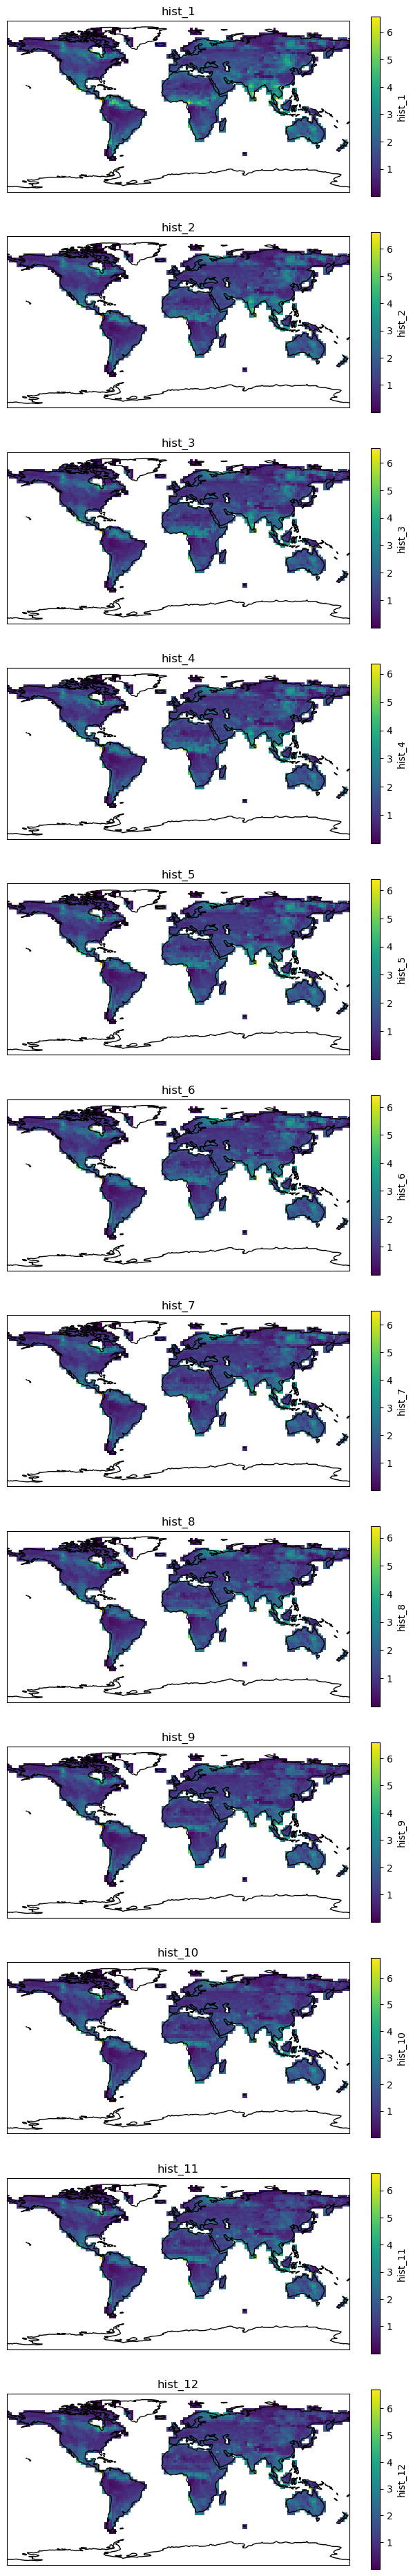

In [24]:
fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=len(score_keys),
    ncols=1,
    figsize=(8, 4 * len(score_keys))
)
depth = 1

for i, s_key in enumerate(score_keys):
    da = all_scores_ds.isel(depth=depth).mean("time")[s_key]
    da.plot(ax=ax[i])
    ax[i].coastlines()
    ax[i].set_title(s_key)



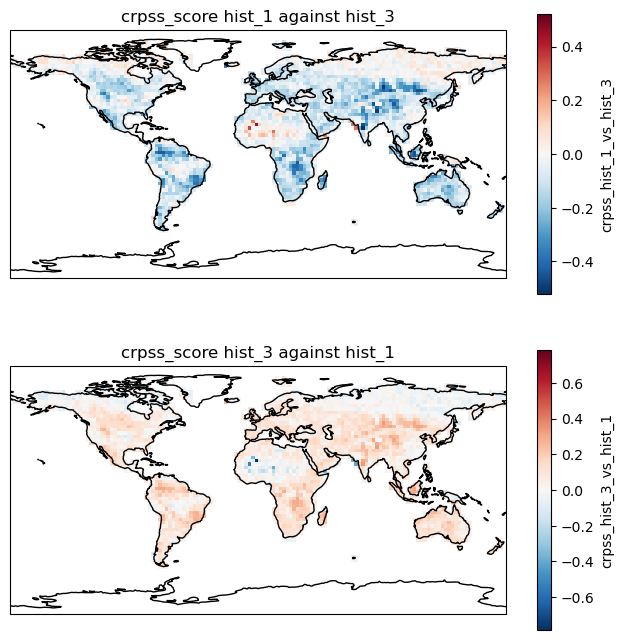

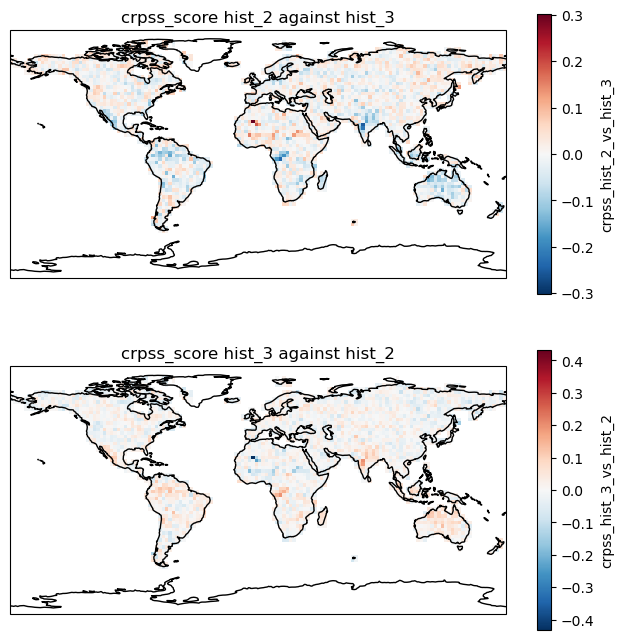

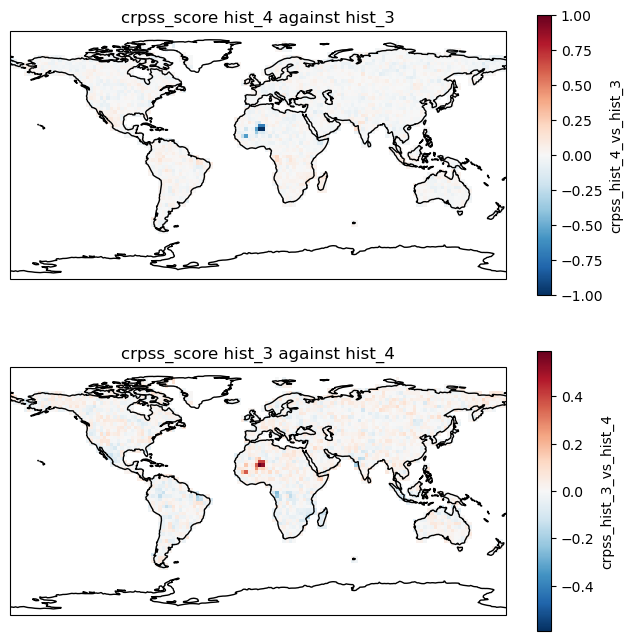

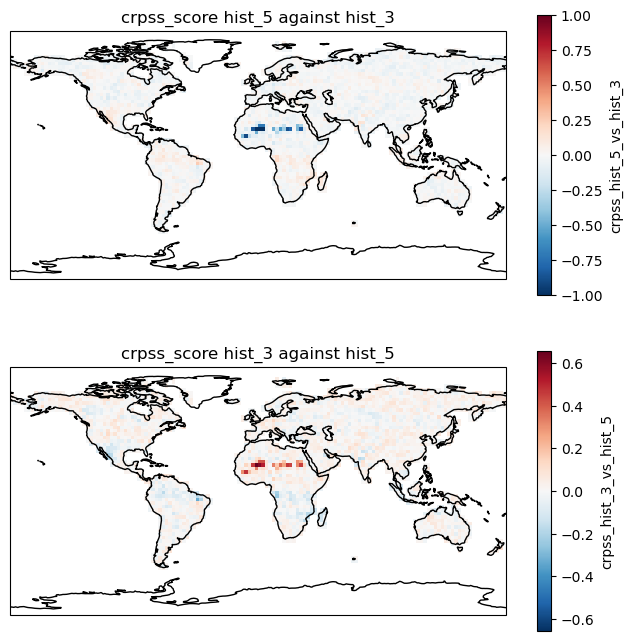

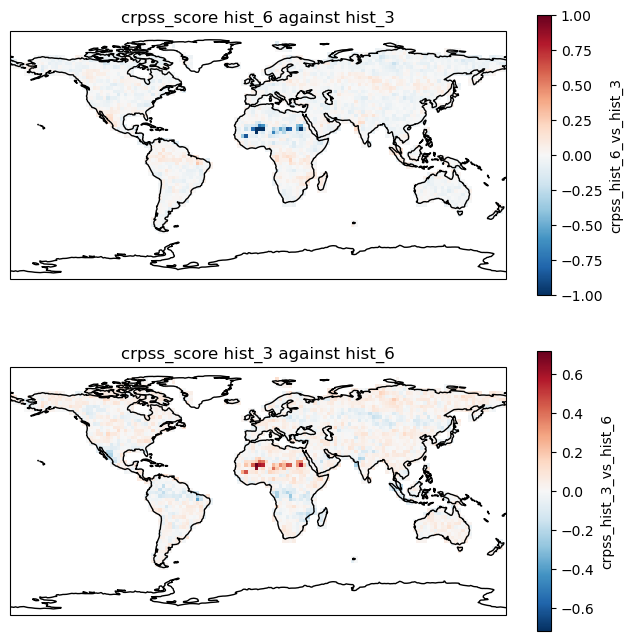

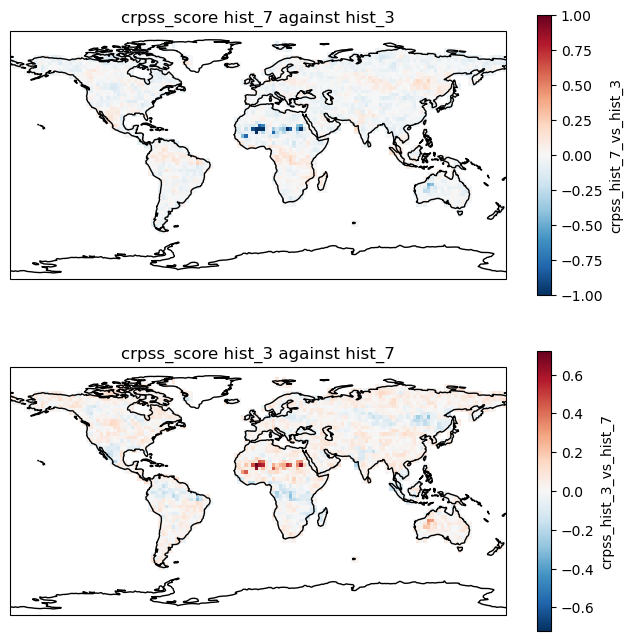

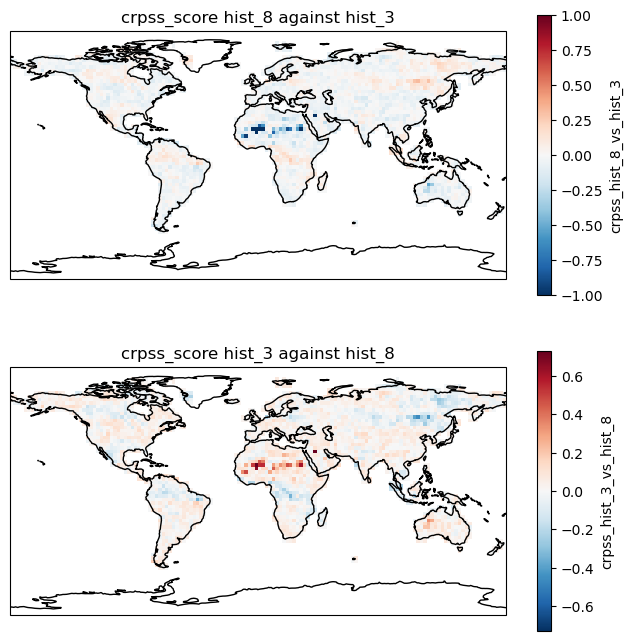

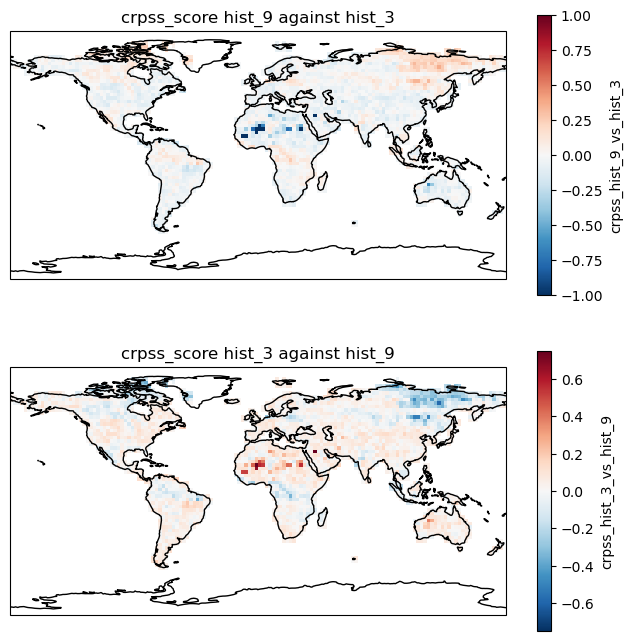

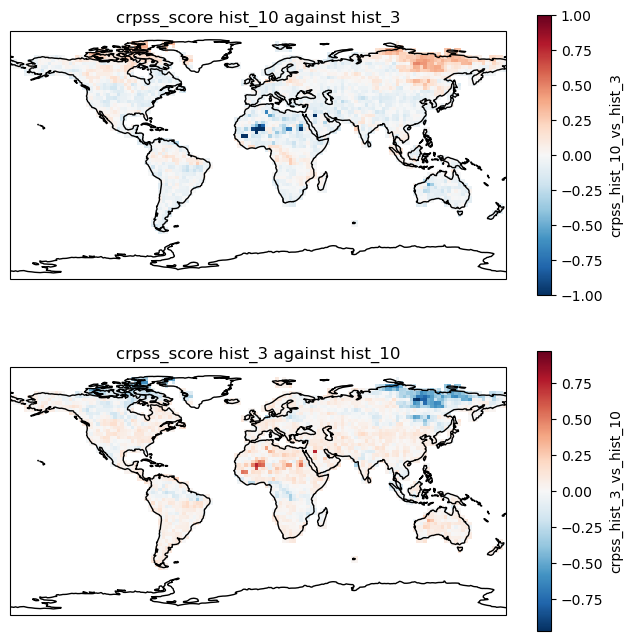

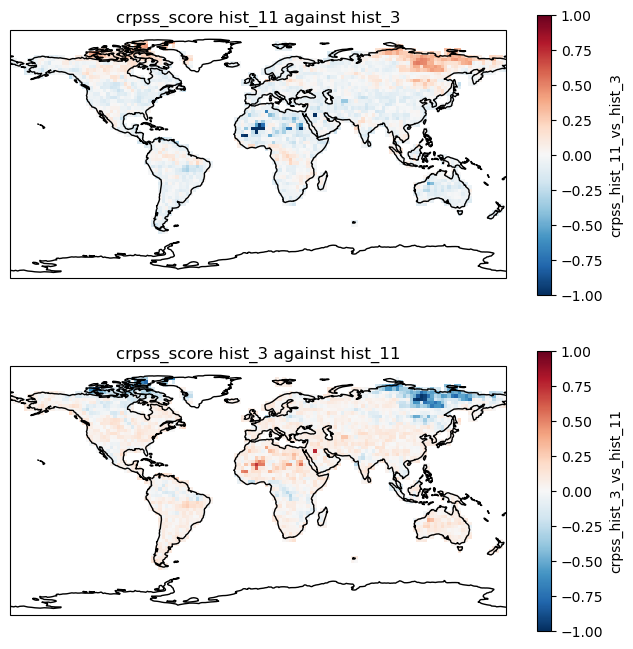

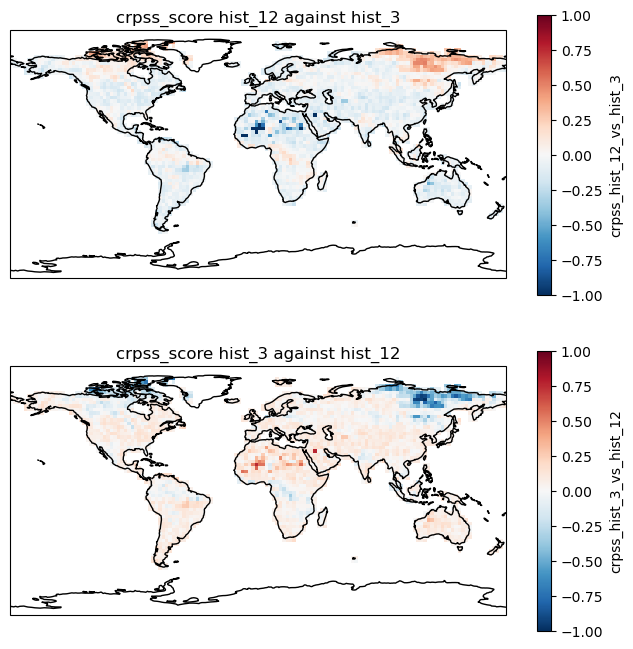

In [27]:
depth = 0

choice = "hist_3"

for i, s_key in enumerate(score_keys):
    if s_key == choice:
        continue
    vs = model_analysis.crps_score.combine_two_crps_and_the_crpss(score_sets[choice].crps_score,score_sets[s_key].crps_score,choice,s_key)

    fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=2,
    ncols=1,
    figsize=(8, 8)
    )
    """
    da = vs.isel(depth=depth).mean("time")[s_key]
    da.plot(ax=ax[0])
    ax[0].coastlines()
    ax[0].set_title(s_key)

    da = vs.isel(depth=depth).mean("time")[choice]
    da.plot(ax=ax[1])
    ax[1].coastlines()
    ax[1].set_title(choice)
    """
    da = vs.isel(depth=depth)[f"crpss_{s_key}_vs_{choice}"].clip(min=-1)
    da.plot(ax=ax[0])
    ax[0].coastlines()
    ax[0].set_title(f"crpss_score {s_key} against {choice}")

    da = vs.isel(depth=depth)[f"crpss_{choice}_vs_{s_key}"].clip(min=-1)
    da.plot(ax=ax[1])
    ax[1].coastlines()
    ax[1].set_title(f"crpss_score {choice} against {s_key}")

    fig_global_crpss.show()
    if safe:
        model.save.save_plot(fig_global_crpss, var = "mrsol",scen= "historical", folder = f"MPI-ESM1-2-LR/variations/history/{s_key}_against_{choice}/local{is_local_data}/month{Month_idx}", name=f"start={start},end={end},depth{depth}")
